# 08 · Decorators: change one policy

## Learning objectives

- Apply Inverter, Retry, Repeat, and Timeout.
- Distinguish failure counts, success counts, and elapsed time.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A **decorator** has one child and changes how its result is interpreted or how long it
may run. Inverter swaps SUCCESS and FAILURE but preserves RUNNING. Retry counts failed
attempts before giving up. Repeat counts successful completions. Timeout bounds elapsed
wall time and invalidates a still-running child when the deadline is observed on a tick.
Neither retry nor timeout automatically reverses side effects.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

1 Try at most three times: RUNNING | Connect: FAILURE
2 Try at most three times: RUNNING | Connect: FAILURE
3 Try at most three times: SUCCESS | Connect: SUCCESS


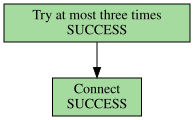

In [3]:
inverted = pt.decorators.Inverter("Not blocked", pt.behaviours.Failure("Blocked?"))
inverted.tick_once()
assert inverted.status is Status.SUCCESS
attempts = {"n": 0}

def flaky():
    attempts["n"] += 1
    return Status.SUCCESS if attempts["n"] >= 3 else Status.FAILURE

retry = pt.decorators.Retry("Try at most three times", Function("Connect", flaky), num_failures=3)
trace(retry, 3)
assert retry.status is Status.SUCCESS
display(diagram(retry))

## Step-by-step implementation
Retry turns early failures into RUNNING so the parent keeps asking. Repeat similarly turns
early successes into RUNNING. A child must tolerate re-entry. Timeout is measured in seconds,
not ticks; its effect is observed at the next tick. A long blocking update defeats the bound.

1 Two successful checks: RUNNING | Check: SUCCESS
2 Two successful checks: SUCCESS | Check: SUCCESS


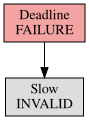

In [4]:
repeat = pt.decorators.Repeat("Two successful checks", pt.behaviours.Success("Check"), num_success=2)
trace(repeat, 2)
assert repeat.status is Status.SUCCESS

import time
timeout = pt.decorators.Timeout("Deadline", CountTicks("Slow", ticks=100), duration=0.02)
timeout.tick_once()
time.sleep(0.04)
timeout.tick_once()
assert timeout.status is Status.FAILURE
assert timeout.decorated.status is Status.INVALID
display(diagram(timeout))

## Interactive demonstration
Use Tick to observe repeated invocations, then Reset to restart the count.

In [5]:
display(playground(lambda: pt.decorators.Repeat(
    "Three completions", CountTicks("Two-tick action", ticks=2), num_success=3)))

## Key observations

Decorators change policy locally. Retrying a payment, grasp, or movement requires an explicit side-effect strategy.

## Exercises

1. Make flaky fail four times.
2. Compare Timeout(Retry(action)) and Retry(Timeout(action)). Which bounds the whole operation?

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 08).

## Summary

A one-child wrapper can express a useful policy. Multiple simultaneous requirements need a parallel composite.